# The Data-Driven Social Engagement Initiative

## Data Cleaning and Exploratory Data Analysis

### Objective
To analyze social media content performance using engagement metrics such as
likes, comments, shares, saves and views, and identify patterns related to
content type, category and posting behaviour.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("social_media_engagement_dataset.csv")

df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (5000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   object 
 1   Timestamp        5000 non-null   object 
 2   Platform         5000 non-null   object 
 3   Content_Type     5000 non-null   object 
 4   Category         5000 non-null   object 
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   object 
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   o

In [5]:
df.columns.tolist()

['Post_ID',
 'Timestamp',
 'Platform',
 'Content_Type',
 'Category',
 'Likes',
 'Comments',
 'Shares',
 'Views',
 'Saves',
 'Follower_Count',
 'Engagement_Rate',
 'Hour_of_Day',
 'Day_of_Week',
 'Hashtag_Count',
 'Content_Length',
 'Sentiment',
 'Influencer_Tier',
 'Has_Media',
 'Is_Verified']

In [6]:
# Check missing values
df.isnull().sum()

Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64

In [7]:
# Check completely duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check whether Post_ID is unique
print("Duplicate Post IDs:", df["Post_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Post IDs: 0


In [9]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

df["Timestamp"].dtype

dtype('<M8[ns]')

In [10]:
print("Invalid timestamps:", df["Timestamp"].isnull().sum())

Invalid timestamps: 0


In [11]:
categorical_cols = [
    "Platform",
    "Content_Type",
    "Category",
    "Day_of_Week",
    "Sentiment",
    "Influencer_Tier"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Platform ---
Platform
Instagram    1283
Twitter       994
Facebook      984
TikTok        758
LinkedIn      502
YouTube       479
Name: count, dtype: int64

--- Content_Type ---
Content_Type
Video             616
Story             568
Poll              384
Post              378
Live              358
Carousel          333
Photo             320
Reel              306
Stitch            259
Retweet           251
Duet              248
Tweet             239
Thread            236
Community Post    135
Document          132
Short             121
Article           116
Name: count, dtype: int64

--- Category ---
Category
Gaming           476
Technology       434
Lifestyle        433
Entertainment    432
Fashion          428
Food             413
Education        413
Sports           401
Travel           398
Health           397
Fitness          393
Business         382
Name: count, dtype: int64

--- Day_of_Week ---
Day_of_Week
Wednesday    727
Monday       719
Tuesday      717
Thursday     71

In [12]:
numeric_cols = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Follower_Count",
    "Engagement_Rate",
    "Hour_of_Day",
    "Hashtag_Count",
    "Content_Length"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Likes,5000.0,7536.838400,10169.129568,18.00,1707.75,4073.5,7783.000,49949.00
Comments,5000.0,339.898800,399.813585,1.00,96.00,212.0,377.000,1999.00
Shares,5000.0,835.233400,1013.769853,2.00,177.00,427.5,1111.500,4997.00
Views,5000.0,110968.397000,181287.350216,527.00,18506.75,40663.5,84226.750,999256.00
Saves,5000.0,753.150600,932.653475,5.00,200.00,424.0,805.000,4985.00
Follower_Count,5000.0,249959.204000,144592.908235,543.00,124560.25,248930.5,374697.500,499815.00
Engagement_Rate,5000.0,11.960148,71.462053,0.05,1.03,2.3,6.245,3510.46
Hour_of_Day,5000.0,11.562600,6.946577,0.00,5.00,12.0,18.000,23.00
Hashtag_Count,5000.0,14.755800,8.666117,0.00,7.00,15.0,22.000,29.00
Content_Length,5000.0,754.508400,576.334039,15.00,280.00,549.0,1226.250,1999.00


In [13]:
print((df[numeric_cols] < 0).sum())

Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Hashtag_Count      0
Content_Length     0
dtype: int64


In [14]:
hour_mismatch = (
    df["Timestamp"].dt.hour != df["Hour_of_Day"]
).sum()

day_mismatch = (
    df["Timestamp"].dt.day_name() != df["Day_of_Week"]
).sum()

print("Hour mismatches:", hour_mismatch)
print("Day mismatches:", day_mismatch)

Hour mismatches: 0
Day mismatches: 0


In [20]:
# Recalculate engagement rate using the dataset's formula

df["Calculated_Engagement_Rate"] = (
    (
        df["Likes"]
        + df["Comments"]
        + df["Shares"]
    )
    / df["Follower_Count"]
) * 100

df["Engagement_Rate_Difference"] = abs(
    df["Engagement_Rate"] - df["Calculated_Engagement_Rate"]
)

print(
    "Rows with noticeable difference:",
    (df["Engagement_Rate_Difference"] > 0.02).sum()
)

print(
    "Maximum difference:",
    df["Engagement_Rate_Difference"].max()
)

Rows with noticeable difference: 0
Maximum difference: 0.004998929578498568


In [21]:
df.nlargest(10, "Engagement_Rate")[
    [
        "Post_ID",
        "Platform",
        "Content_Type",
        "Likes",
        "Comments",
        "Shares",
        "Saves",
        "Follower_Count",
        "Engagement_Rate"
    ]
]

,Post_ID,Platform,Content_Type,Likes,Comments,Shares,Saves,Follower_Count,Engagement_Rate
4615,POST_02510,TikTok,Stitch,42869,1208,2226,1300,1319,3510.46
3918,POST_02248,TikTok,Video,45677,1232,4349,2341,3840,1334.84
4129,POST_01362,Instagram,Reel,8822,313,225,957,857,1092.18
1846,POST_01478,TikTok,Duet,44001,1515,531,1073,4269,1078.64
4243,POST_01373,TikTok,Stitch,48254,720,1415,1170,5102,987.63
3948,POST_03870,Instagram,Reel,5723,356,111,135,659,939.30
4807,POST_01501,Facebook,Video,7192,182,813,525,1003,816.25
1693,POST_02569,TikTok,Video,38052,902,289,2069,5443,720.98
4394,POST_01874,TikTok,Duet,36683,633,597,472,6134,618.08
4123,POST_03002,TikTok,Duet,30501,773,2329,2551,5541,606.44


In [24]:
# Total active engagement generated by each post
df["Total_Interactions"] = (
    df["Likes"]
    + df["Comments"]
    + df["Shares"]
    + df["Saves"]
)

# Extract month for time-based analysis
df["Month"] = df["Timestamp"].dt.to_period("M").astype(str)

df[
    [
        "Post_ID",
        "Timestamp",
        "Total_Interactions",
        "Engagement_Rate",
        "Month"
    ]
].head()

,Post_ID,Timestamp,Total_Interactions,Engagement_Rate,Month
0,POST_04552,2024-01-01 01:42:00,8605,3.85,2024-01
1,POST_02171,2024-01-01 05:05:00,2124,0.63,2024-01
2,POST_00210,2024-01-01 09:18:00,2084,0.78,2024-01
3,POST_01548,2024-01-01 10:58:00,1886,0.27,2024-01
4,POST_01350,2024-01-01 13:12:00,10470,15.31,2024-01


In [27]:
# Remove temporary validation columns
df.drop(
    columns=[
        "Calculated_Engagement_Rate",
        "Engagement_Rate_Difference"
    ],
    errors="ignore",
    inplace=True
)

In [30]:
df.to_csv(
    "cleaned_social_media_engagement_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Exploratory Data Analysis

### 1. Dataset Time Coverage
First, we examine the time period covered by the dataset.

In [31]:
print("Start Date:", df["Timestamp"].min())
print("End Date:", df["Timestamp"].max())
print("Total Posts:", len(df))

Start Date: 2024-01-01 01:42:00
End Date: 2025-12-31 21:56:00
Total Posts: 5000


### 2. Distribution of Posts Across Platforms
This analysis shows how the dataset is distributed across different social media platforms.

In [32]:
platform_counts = df["Platform"].value_counts()
platform_counts

Platform
Instagram    1283
Twitter       994
Facebook      984
TikTok        758
LinkedIn      502
YouTube       479
Name: count, dtype: int64

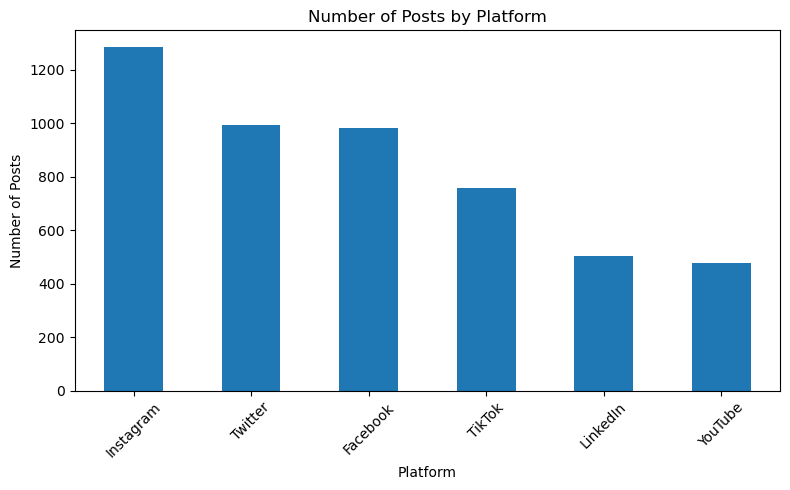

In [33]:
platform_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**  
Instagram has the highest representation in the dataset with 1,283 posts, followed by Twitter and Facebook. YouTube has the lowest number of posts with 479 observations. Therefore, the dataset is not equally distributed across all platforms.

### 3. Median Engagement Rate by Platform
Median engagement rate is used to reduce the influence of extremely high engagement-rate values.

In [34]:
platform_engagement = (
    df.groupby("Platform")["Engagement_Rate"]
      .median()
      .sort_values(ascending=False)
)

platform_engagement

Platform
TikTok       11.015
YouTube       4.140
Instagram     2.120
Facebook      2.005
Twitter       1.420
LinkedIn      0.560
Name: Engagement_Rate, dtype: float64

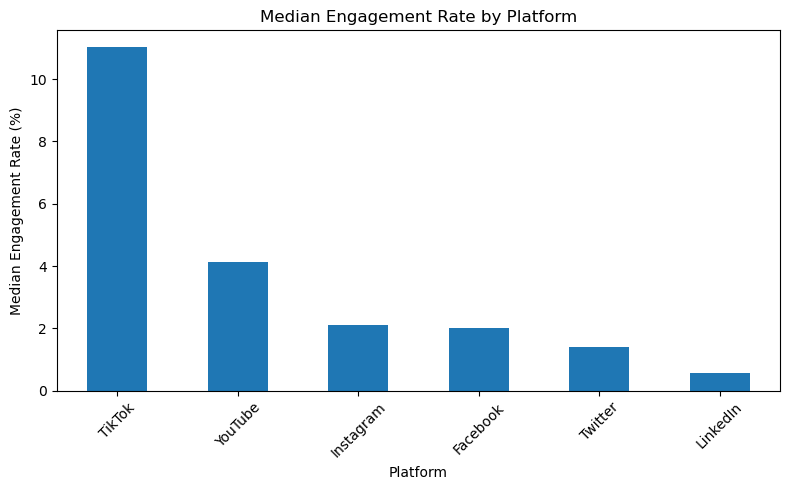

In [35]:
platform_engagement.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Median Engagement Rate by Platform")
plt.xlabel("Platform")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**  
TikTok shows the highest median engagement rate at approximately 11.02%, followed by YouTube at 4.14%. LinkedIn records the lowest median engagement rate at 0.56%. This suggests that short-form/video-oriented platforms in this dataset tend to generate stronger engagement relative to follower count.

### 4. Median Engagement Rate by Content Category
This analysis identifies which content categories generate stronger audience engagement.

In [36]:
category_engagement = (
    df.groupby("Category")["Engagement_Rate"]
      .median()
      .sort_values(ascending=False)
)

category_engagement

Category
Travel           2.635
Technology       2.605
Lifestyle        2.520
Entertainment    2.390
Education        2.370
Fitness          2.360
Sports           2.360
Food             2.300
Gaming           2.245
Health           2.190
Fashion          1.980
Business         1.900
Name: Engagement_Rate, dtype: float64

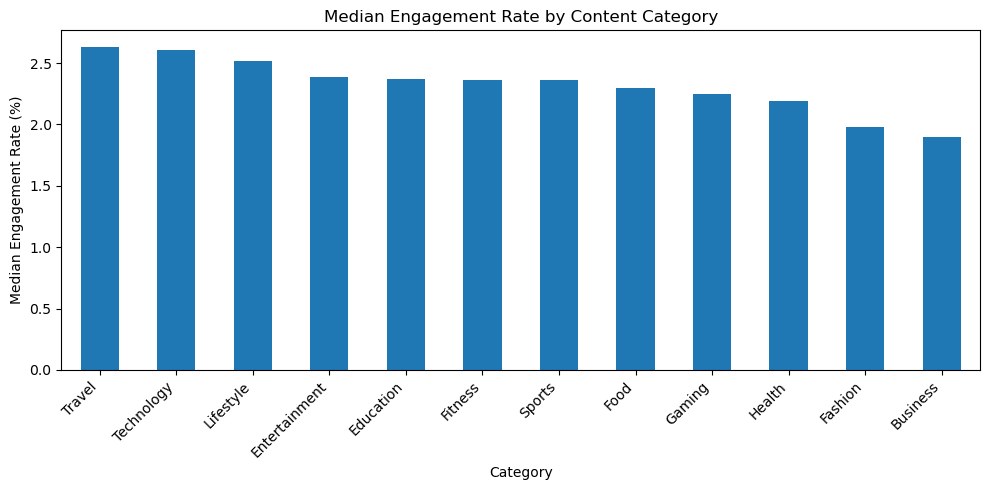

In [37]:
category_engagement.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Median Engagement Rate by Content Category")
plt.xlabel("Category")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:**  
Travel content records the highest median engagement rate (2.64%), closely followed by Technology (2.61%) and Lifestyle (2.52%). Business content has the lowest median engagement rate (1.90%). However, the differences between most categories are relatively small compared with the differences observed across platforms.

### 5. Median Engagement Rate by Content Type

This analysis compares different content formats to identify which formats tend to generate stronger audience engagement.

In [38]:
content_engagement = (
    df.groupby("Content_Type")["Engagement_Rate"]
      .agg(["median", "count"])
      .sort_values("median", ascending=False)
)

content_engagement

,median,count
Content_Type,,
Duet,11.545,248
Stitch,10.680,259
Video,4.560,616
Short,3.950,121
Community Post,3.910,135
Live,2.410,358
Carousel,2.250,333
Photo,2.125,320
Reel,2.040,306


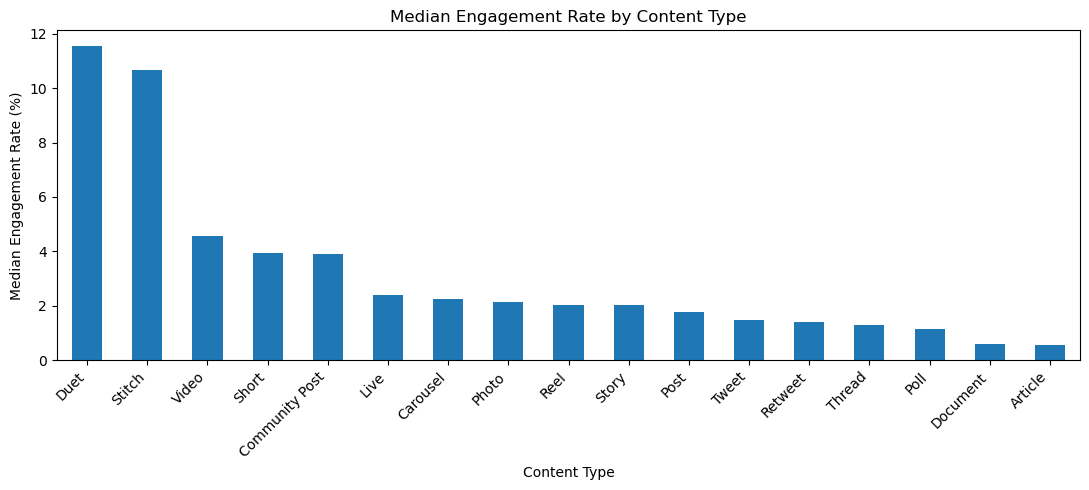

In [39]:
content_engagement["median"].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Median Engagement Rate by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:**  
Duet and Stitch content formats show substantially higher median engagement rates than other content types, while formats such as Documents and Articles record comparatively lower engagement. However, content type may also be influenced by the platform on which it is available, so these results should not be interpreted as a direct causal effect of format alone.

### 6. Median Engagement Rate by Day of Week

This analysis examines whether audience engagement differs depending on the day on which content is posted.

In [40]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_engagement = (
    df.groupby("Day_of_Week")["Engagement_Rate"]
      .median()
      .reindex(day_order)
)

day_engagement

Day_of_Week
Monday       2.160
Tuesday      2.260
Wednesday    2.370
Thursday     2.540
Friday       2.370
Saturday     2.030
Sunday       2.315
Name: Engagement_Rate, dtype: float64

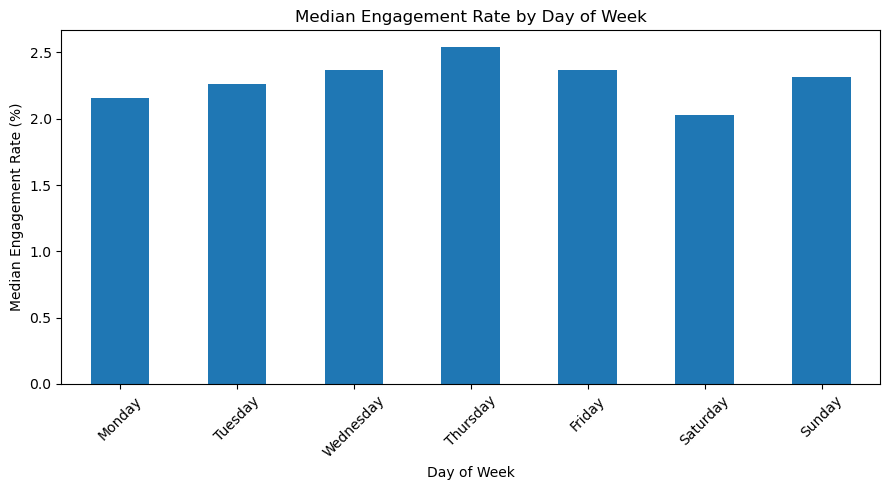

In [41]:
day_engagement.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Median Engagement Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**  
Thursday records the highest median engagement rate among the days of the week, while Saturday shows the lowest. However, the differences across days are relatively small, suggesting that day of posting may have a weaker relationship with engagement than platform or content type.

### 7. Median Engagement Rate by Posting Hour

This analysis examines how engagement varies across different posting hours.

In [42]:
hour_engagement = (
    df.groupby("Hour_of_Day")["Engagement_Rate"]
      .median()
)

hour_engagement

Hour_of_Day
0     2.020
1     2.270
2     2.055
3     2.160
4     2.070
5     2.100
6     2.235
7     2.560
8     1.895
9     1.960
10    2.050
11    2.545
12    2.240
13    2.520
14    2.610
15    2.620
16    2.810
17    2.255
18    2.255
19    2.390
20    2.750
21    2.145
22    2.775
23    2.055
Name: Engagement_Rate, dtype: float64

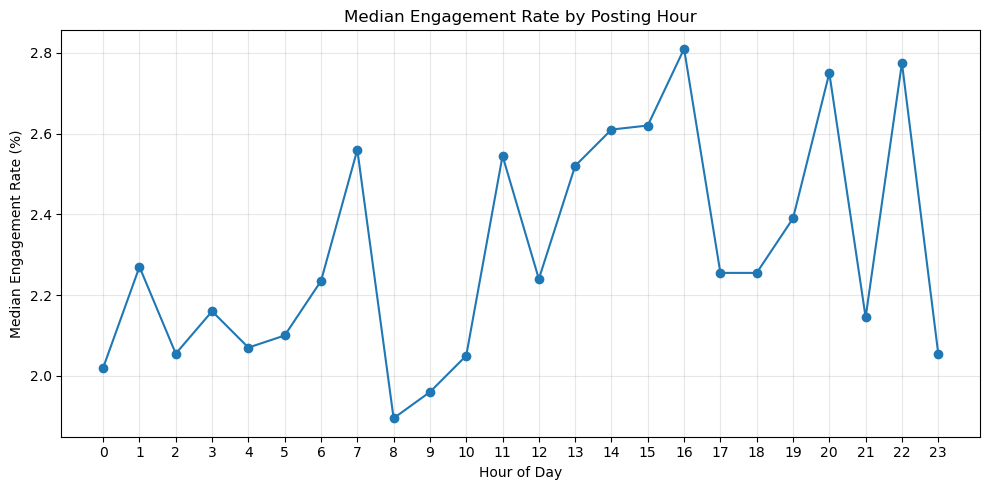

In [43]:
hour_engagement.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Median Engagement Rate by Posting Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**  
Engagement varies across posting hours, with notable peaks around 16:00, 20:00 and 22:00. The lowest median engagement is observed around 08:00. This suggests that late afternoon and evening hours may provide stronger engagement opportunities in this dataset.

### 8. Engagement by Sentiment

This analysis compares engagement rates across the sentiment labels available in the dataset.

In [44]:
sentiment_engagement = (
    df.groupby("Sentiment")["Engagement_Rate"]
      .agg(["median", "count"])
      .sort_values("median", ascending=False)
)

sentiment_engagement

,median,count
Sentiment,,
Negative,2.42,750
Positive,2.37,2503
Neutral,2.13,1747


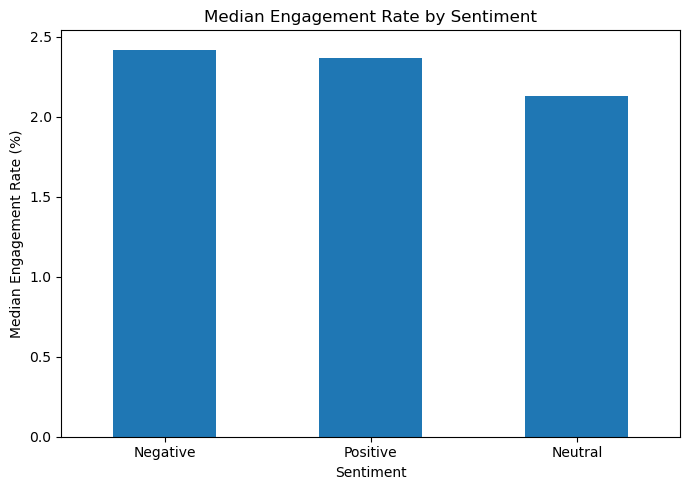

In [45]:
sentiment_engagement["median"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Median Engagement Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**  
Negative-sentiment content shows the highest median engagement rate, closely followed by positive content, while neutral content records the lowest engagement. This indicates that emotionally charged content, whether negative or positive, may attract more interaction than neutral content.

### 9. Engagement by Influencer Tier

This analysis examines whether engagement rates vary across different influencer audience sizes.

In [46]:
tier_engagement = (
    df.groupby("Influencer_Tier")["Engagement_Rate"]
      .agg(["median", "count"])
      .sort_values("median", ascending=False)
)

tier_engagement

,median,count
Influencer_Tier,,
Nano,90.04,97
Micro,17.32,427
Mid-tier,6.83,483
Macro,1.75,3993


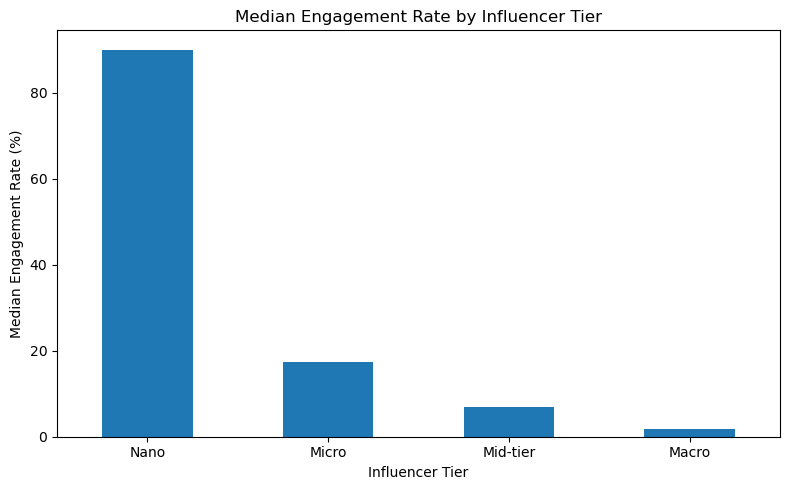

In [47]:
tier_engagement["median"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Median Engagement Rate by Influencer Tier")
plt.xlabel("Influencer Tier")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**  
Nano influencers show substantially higher median engagement rates compared with Micro, Mid-tier, and Macro influencers. However, engagement rate is calculated relative to follower count, which can naturally produce higher percentage values for accounts with smaller audiences. Therefore, this result should be interpreted as stronger engagement relative to audience size rather than greater absolute performance.

### 10. Engagement by Media Presence

In [48]:
media_engagement = (
    df.groupby("Has_Media")["Engagement_Rate"]
      .agg(["median", "count"])
)

media_engagement

,median,count
Has_Media,,
False,2.11,775
True,2.35,4225


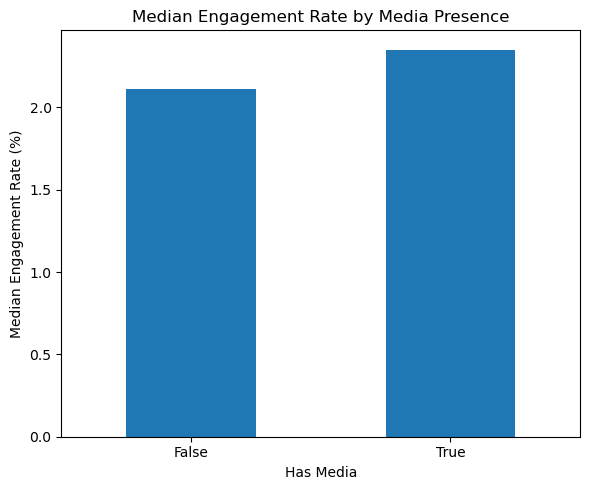

In [49]:
media_engagement["median"].plot(
    kind="bar",
    figsize=(6, 5)
)

plt.title("Median Engagement Rate by Media Presence")
plt.xlabel("Has Media")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**  
Posts containing media show a slightly higher median engagement rate (2.35%) than posts without media (2.11%). This suggests that media presence may be associated with improved audience engagement, although the difference is relatively modest.

### 11. Engagement by Verification Status

In [50]:
verified_engagement = (
    df.groupby("Is_Verified")["Engagement_Rate"]
      .agg(["median", "count"])
)

verified_engagement

,median,count
Is_Verified,,
False,2.29,3693
True,2.31,1307


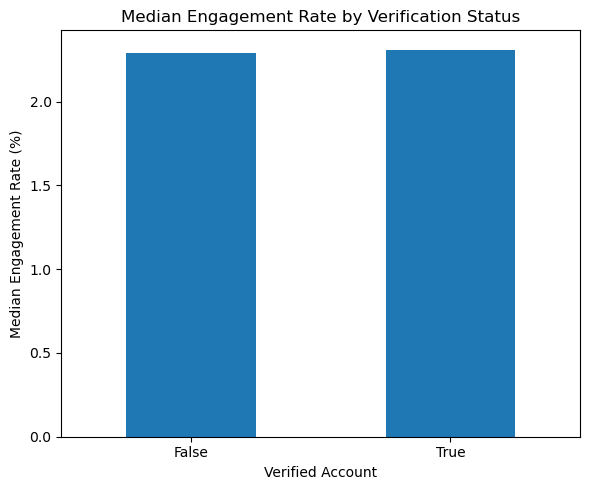

In [51]:
verified_engagement["median"].plot(
    kind="bar",
    figsize=(6, 5)
)

plt.title("Median Engagement Rate by Verification Status")
plt.xlabel("Verified Account")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**  
Verified and non-verified accounts show nearly identical median engagement rates (2.31% and 2.29%, respectively). This indicates that verification status alone has little apparent relationship with engagement in this dataset.

In [52]:
corr_cols = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Follower_Count",
    "Engagement_Rate",
    "Hour_of_Day",
    "Hashtag_Count",
    "Content_Length",
    "Total_Interactions"
]

correlation = df[corr_cols].corr()

correlation.round(2)

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length,Total_Interactions
Likes,1.00,0.61,0.56,0.38,0.43,0.00,0.23,0.02,0.01,-0.30,0.99
Comments,0.61,1.00,0.52,0.41,0.43,0.05,0.14,0.03,-0.00,-0.31,0.65
Shares,0.56,0.52,1.00,0.36,0.34,0.00,0.12,0.01,0.01,-0.23,0.63
Views,0.38,0.41,0.36,1.00,0.62,0.02,0.08,0.02,0.00,-0.26,0.43
Saves,0.43,0.43,0.34,0.62,1.00,0.03,0.08,0.02,0.00,-0.28,0.51
Follower_Count,0.00,0.05,0.00,0.02,0.03,1.00,-0.21,-0.02,0.02,0.00,0.01
Engagement_Rate,0.23,0.14,0.12,0.08,0.08,-0.21,1.00,-0.01,-0.01,-0.07,0.23
Hour_of_Day,0.02,0.03,0.01,0.02,0.02,-0.02,-0.01,1.00,0.00,0.02,0.02
Hashtag_Count,0.01,-0.00,0.01,0.00,0.00,0.02,-0.01,0.00,1.00,-0.00,0.01
Content_Length,-0.30,-0.31,-0.23,-0.26,-0.28,0.00,-0.07,0.02,-0.00,1.00,-0.32


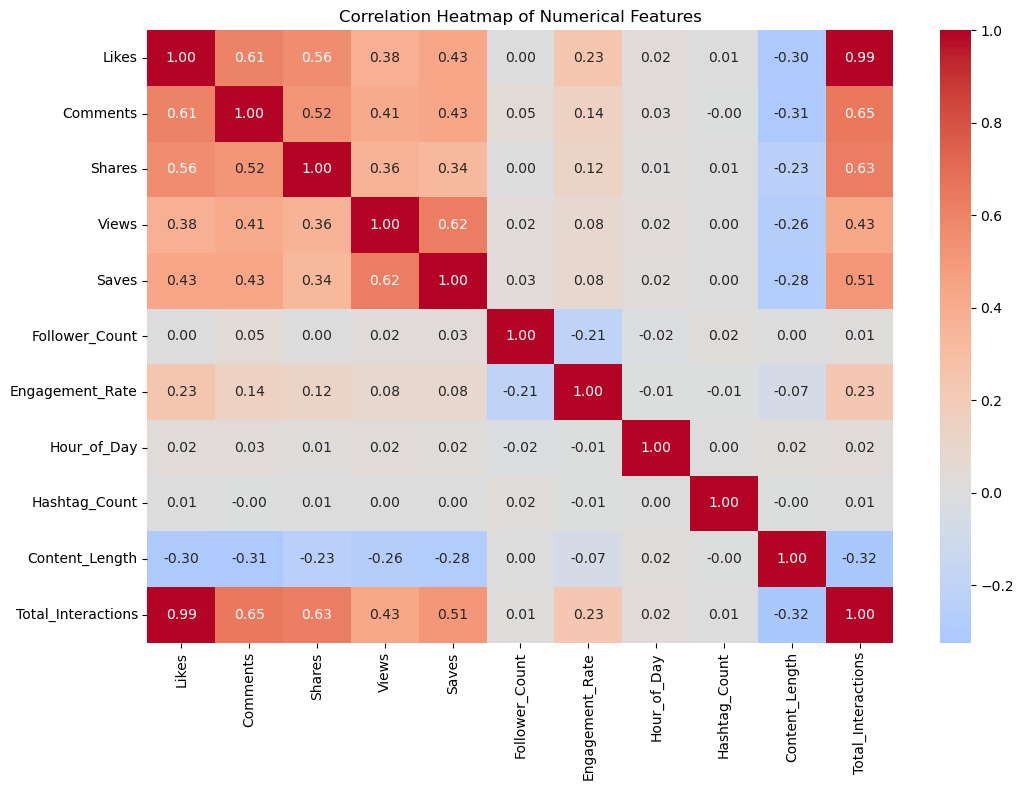

In [53]:
import seaborn as sns
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Observation:**  
Likes, comments, shares, views and saves show positive correlations with one another, indicating that posts performing strongly on one engagement metric often perform well on others. Content length shows a moderate negative relationship with several engagement metrics, suggesting that shorter content may be associated with greater interaction.

Follower count has a weak negative correlation with engagement rate, partly because engagement rate is calculated relative to follower count. Posting hour and hashtag count show almost no overall linear correlation with engagement rate.

The strong correlation between Total_Interactions and individual engagement metrics is expected because Total_Interactions is directly calculated from likes, comments, shares and saves.

## Key Findings from Exploratory Data Analysis

- TikTok records the highest median engagement rate, while LinkedIn records the lowest.
- Travel, Technology, and Lifestyle are among the strongest-performing content categories.
- Duet and Stitch formats show particularly high median engagement, although this is partly associated with platform-specific content formats.
- Thursday records the highest median engagement among days of the week, while differences across days remain relatively small.
- Higher engagement is observed at selected late-afternoon and evening posting hours, particularly around 16:00, 20:00, and 22:00.
- Emotionally charged content shows slightly higher engagement than neutral content.
- Nano influencers exhibit much higher engagement rates relative to their follower base, while Macro influencers show lower percentage engagement.
- Posts containing media show slightly higher engagement than posts without media.
- Verification status shows almost no difference in median engagement.
- Engagement metrics such as likes, comments, shares, views, and saves are positively related, while content length shows a moderate negative association with interaction levels.
- Hashtag count and posting hour show little overall linear correlation with engagement rate.